In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd

from dd_kable_analysis.config_loader import load_config

In [3]:
from dd_kable_analysis.mvpa import (
    get_subject_cache_path,
    load_subject_prep_cache,
    roi_to_cols_from_atlas_labels,
)

In [2]:
cfg = load_config()

In [10]:
sub_id = 'dmp0356'

In [4]:
from dd_kable_analysis.mvpa import build_subject_behav_bold_df
from dd_kable_analysis.mvpa.features import prepare_subject_for_atlas_mvpa

In [7]:
pauli_dir = Path(cfg.masks_dir) / 'pauli_subcort_rois_neurovault_collection_3145'
ap = pauli_dir / 'pauli_roi_atlas_thr0.50_to-groupmask.nii.gz'

In [ ]:
ap_labels_file = pauli_dir / 'pauli_roi_atlas_thr0.50_to-groupmask_labels.tsv'
ap_labels = pd.read_csv(ap_labels_file, sep='\t')
# verify it is 3
ap_labels

,label,name,cit168_volume
0,1,Pu,1
1,2,Ca,2
2,3,NAC,3
3,4,EXA,4
4,5,GPe,5
5,6,GPi,6
6,7,SNc,7
7,8,RN,8
8,9,SNr,9
9,10,PBP,10


In [12]:
pauli_dir

PosixPath('/oak/stanford/groups/russpold/users/buckholtz/DD_Kable/derivatives/masks/pauli_subcort_rois_neurovault_collection_3145')

In [17]:
pauli_labels_file = pauli_dir / 'pauli_roi_atlas_thr0.50_to-groupmask_labels.tsv'
pauli_labels = pd.read_csv(pauli_labels_file, sep='\t')
# verify it is 3
roi_label = 3
roi_name = pauli_labels.loc[pauli_labels['label'] == roi_label, 'name'].iloc[0]
print('ROI label', roi_label, '=', roi_name)

out = build_subject_behav_bold_df(cfg, sub_id=sub_id, strict=True, verbose=False)

prep = prepare_subject_for_atlas_mvpa(
    out.behav_bold_df,
    atlas_img=ap,
    cfg=cfg,
    y_col='amount',
    group_col='run',
    beta_col='beta_file',
    standardize_X=False,
    verbose=False,
)


ROI label 3 = NAC


In [18]:
cols = prep.roi_to_cols[int(roi_label)]
X_roi = prep.X_all[:, cols]
y = prep.y
runs = prep.groups.astype(str)

print('X_roi shape:', X_roi.shape)
print('n_runs:', len(np.unique(runs)), 'runs:', np.unique(runs))

X_roi shape: (114, 122)
n_runs: 4 runs: ['1' '2' '3' '4']


In [25]:
def cross_run_bin_pattern_consistency(X_roi, y, runs, n_bins=4, min_trials_per_bin=3):
    X_roi = np.asarray(X_roi)
    y = np.asarray(y, float)
    runs = np.asarray(runs).astype(str)

    uniq_runs = np.unique(runs)
    patterns = {}

    for r in uniq_runs:
        m = runs == r
        yr = y[m]
        Xr = X_roi[m, :]

        # quantile bins within run (creates pseudo-repeats)
        bins = pd.qcut(yr, q=n_bins, labels=False, duplicates='drop')
        nb = int(np.max(bins)) + 1 if len(bins) else 0
        if nb < 2:
            continue

        pats = []
        for b in range(nb):
            mb = np.asarray(bins) == b
            if int(mb.sum()) < min_trials_per_bin:
                pats = None
                break
            pats.append(Xr[mb].mean(axis=0))

        if pats is not None:
            patterns[str(r)] = np.vstack(pats)  # (nb, n_vox)

    kept = sorted(patterns.keys())
    if len(kept) < 2:
        return dict(mean_r=np.nan, pair_rs=[], kept_runs=kept)

    pair_rs = []
    for i in range(len(kept)):
        for j in range(i + 1, len(kept)):
            P1, P2 = patterns[kept[i]], patterns[kept[j]]
            nb = min(P1.shape[0], P2.shape[0])
            rs = []
            for b in range(nb):
                v1, v2 = P1[b], P2[b]
                if np.std(v1) == 0 or np.std(v2) == 0:
                    continue
                rs.append(float(np.corrcoef(v1, v2)[0, 1]))
            if rs:
                pair_rs.append(float(np.mean(rs)))

    return dict(
        mean_r=float(np.mean(pair_rs)) if pair_rs else np.nan,
        pair_rs=pair_rs,
        kept_runs=kept,
        patterns=patterns,
    )


In [26]:
res = cross_run_bin_pattern_consistency(X_roi, y, runs, n_bins=4, min_trials_per_bin=3)
print(
    f'Pauli ROI {roi_label} ({roi_name}) cross-run bin-pattern consistency:',
    res['mean_r'],
)
print('run-pair values:', res['pair_rs'])

Pauli ROI 3 (NAC) cross-run bin-pattern consistency: -0.03144294553770688
run-pair values: [0.0460380652050278, -0.213997111035841, 0.0691015162301695, 0.0581823892114138, 0.044698392269126225, -0.19268092510613763]


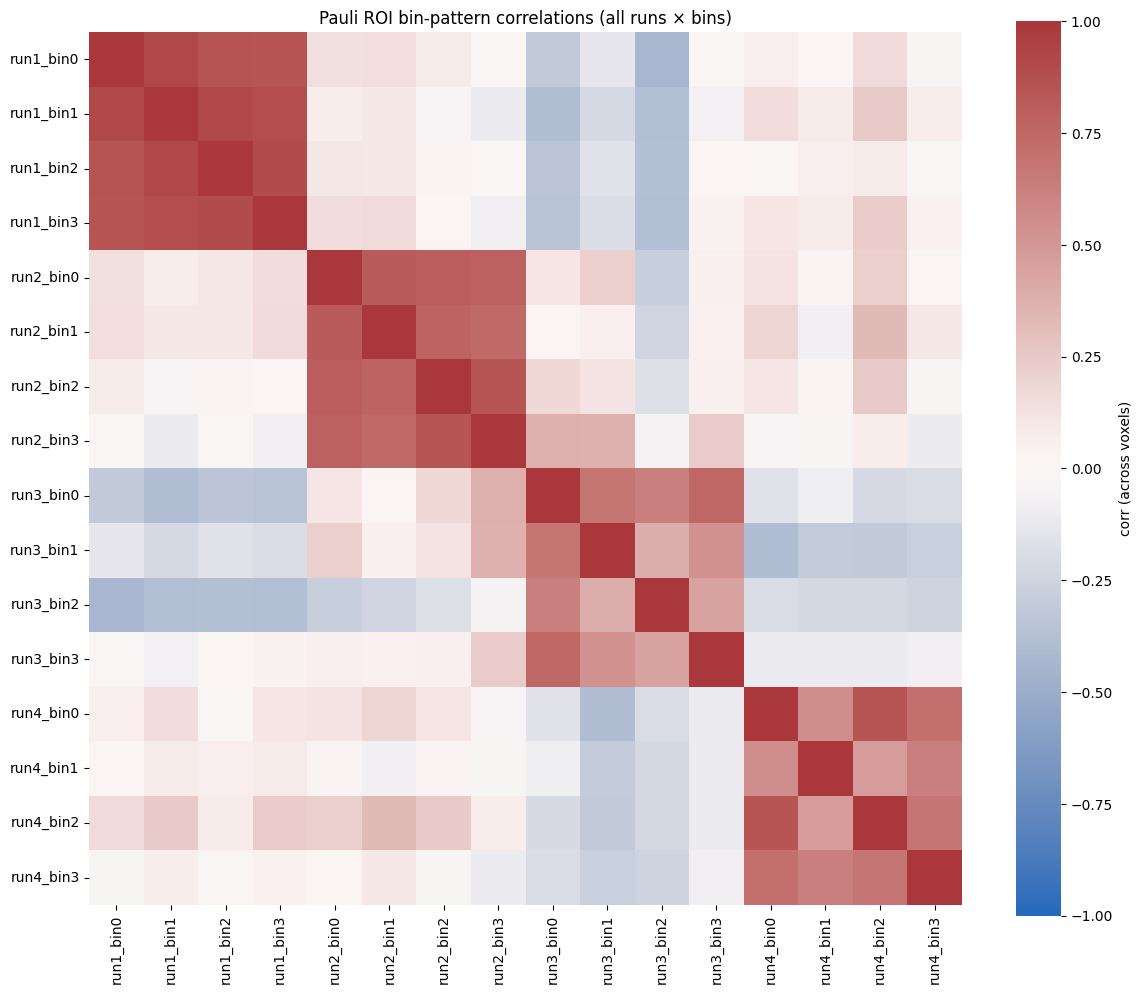

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns

runs = sorted(res['patterns'].keys())

# stack into (n_patterns, n_vox)
rows = []
row_index = []
for r in runs:
    P = np.asarray(res['patterns'][r])
    for b in range(P.shape[0]):
        rows.append(P[b, :])
        row_index.append((str(r), int(b)))  # (run, bin)

M = np.vstack(rows)  # shape: (sum_bins_over_runs, n_vox)

# 16x16 correlation across voxels (row-wise correlation)
C = np.corrcoef(M)  # correlates rows with rows

# nice labels
labels = [f'run{r}_bin{b}' for (r, b) in row_index]
corr_df = pd.DataFrame(C, index=labels, columns=labels)


plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_df,
    vmin=-1,
    vmax=1,
    cmap='vlag',
    square=True,
    cbar_kws={'label': 'corr (across voxels)'},
)
plt.title('Pauli ROI bin-pattern correlations (all runs × bins)')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [33]:
# make seabornimage of the correlation matrix of res['patterns']['1']
for run in ['1', '2', '3', '4']:
    print(np.corrcoef(res['patterns'][run]))


[[1.         0.91441907 0.85909155 0.85049315]
 [0.91441907 1.         0.91823094 0.88627619]
 [0.85909155 0.91823094 1.         0.89785331]
 [0.85049315 0.88627619 0.89785331 1.        ]]
[[1.         0.81867564 0.80912666 0.7865301 ]
 [0.81867564 1.         0.77466439 0.73575484]
 [0.80912666 0.77466439 1.         0.84781645]
 [0.7865301  0.73575484 0.84781645 1.        ]]
[[1.         0.68091564 0.62569587 0.75495735]
 [0.68091564 1.         0.38310806 0.53595698]
 [0.62569587 0.38310806 1.         0.44582544]
 [0.75495735 0.53595698 0.44582544 1.        ]]
[[1.         0.55440771 0.84619112 0.71760526]
 [0.55440771 1.         0.48248383 0.63094378]
 [0.84619112 0.48248383 1.         0.67782883]
 [0.71760526 0.63094378 0.67782883 1.        ]]


In [ ]:
from __future__ import annotations

from typing import Any

import numpy as np
import pandas as pd

from dd_kable_analysis.mvpa import build_subject_behav_bold_df
from dd_kable_analysis.mvpa.features import prepare_subject_for_atlas_mvpa


def _cross_run_bin_pattern_consistency(
    X_roi: np.ndarray,
    y: np.ndarray,
    runs: np.ndarray,
    *,
    n_bins: int = 4,
    min_trials_per_bin: int = 3,
    return_patterns: bool = False,
) -> dict:
    X_roi = np.asarray(X_roi)
    y = np.asarray(y, float)
    runs = np.asarray(runs).astype(str)

    uniq_runs = np.unique(runs)
    patterns: dict[str, np.ndarray] = {}

    for r in uniq_runs:
        m = runs == r
        yr = y[m]
        Xr = X_roi[m, :]

        # quantile bins within run (pseudo-repeats)
        bins = pd.qcut(yr, q=n_bins, labels=False, duplicates='drop')
        nb = int(np.max(bins)) + 1 if len(bins) else 0
        if nb < 2:
            continue

        pats = []
        for b in range(nb):
            mb = np.asarray(bins) == b
            if int(mb.sum()) < min_trials_per_bin:
                pats = None
                break
            pats.append(Xr[mb].mean(axis=0))

        if pats is not None:
            patterns[str(r)] = np.vstack(pats)  # (nb, n_vox)

    kept = sorted(patterns.keys())
    if len(kept) < 2:
        out = dict(mean_r=np.nan, pair_rs=[], kept_runs=kept)
        if return_patterns:
            out['patterns'] = patterns
        return out

    pair_rs = []
    pair_names = []
    for i in range(len(kept)):
        for j in range(i + 1, len(kept)):
            r1, r2 = kept[i], kept[j]
            P1, P2 = patterns[r1], patterns[r2]
            nb = min(P1.shape[0], P2.shape[0])

            rs = []
            for b in range(nb):
                v1, v2 = P1[b], P2[b]
                if np.std(v1) == 0 or np.std(v2) == 0:
                    continue
                rs.append(float(np.corrcoef(v1, v2)[0, 1]))

            if rs:
                pair_rs.append(float(np.mean(rs)))
                pair_names.append((r1, r2))

    out = dict(
        mean_r=float(np.mean(pair_rs)) if pair_rs else np.nan,
        pair_rs=pair_rs,
        pair_names=pair_names,
        kept_runs=kept,
    )
    if return_patterns:
        out['patterns'] = patterns
    return out


def pauli_noise_ceiling_subject_roi(
    cfg: Any,
    sub_id: str,
    *,
    atlas_img: Any,  # path or Nifti1Image label atlas (Pauli label atlas)
    roi_label: int,  # integer label in atlas_img
    y_col: str = 'amount',
    beta_col: str = 'beta_file',
    group_col: str = 'run',
    n_bins: int = 4,
    min_trials_per_bin: int = 3,
    min_voxels: int = 1,
    return_patterns: bool = False,
    verbose: bool = False,
) -> dict:
    """
    Compute Method-A noise ceiling (cross-run binned-pattern consistency) for one subject and one ROI label.

    Returns a dict with:
      - sub_id, roi_label
      - n_trials, n_runs, n_vox
      - mean_r, pair_rs, pair_names, kept_runs
      - optionally patterns (dict run -> (n_bins, n_vox))
    """
    out = build_subject_behav_bold_df(cfg, sub_id=sub_id, strict=True, verbose=verbose)

    prep = prepare_subject_for_atlas_mvpa(
        out.behav_bold_df,
        atlas_img=atlas_img,
        cfg=cfg,
        y_col=y_col,
        beta_col=beta_col,
        group_col=group_col,
        standardize_X=False,
        verbose=verbose,
    )

    cols = prep.roi_to_cols.get(int(roi_label), None)
    if cols is None or len(cols) == 0:
        return dict(
            sub_id=str(sub_id),
            roi_label=int(roi_label),
            n_trials=int(len(prep.y)),
            n_runs=int(len(np.unique(prep.groups))),
            n_vox=0,
            mean_r=np.nan,
            pair_rs=[],
            pair_names=[],
            kept_runs=[],
            error='roi_label not found in roi_to_cols (or empty after masking)',
        )

    X_roi = prep.X_all[:, cols]
    if X_roi.shape[1] < min_voxels:
        return dict(
            sub_id=str(sub_id),
            roi_label=int(roi_label),
            n_trials=int(len(prep.y)),
            n_runs=int(len(np.unique(prep.groups))),
            n_vox=int(X_roi.shape[1]),
            mean_r=np.nan,
            pair_rs=[],
            pair_names=[],
            kept_runs=[],
            error=f'ROI has too few voxels (min_voxels={min_voxels})',
        )

    y = prep.y
    runs = prep.groups.astype(str)

    res = _cross_run_bin_pattern_consistency(
        X_roi,
        y,
        runs,
        n_bins=n_bins,
        min_trials_per_bin=min_trials_per_bin,
        return_patterns=return_patterns,
    )

    return dict(
        sub_id=str(sub_id),
        roi_label=int(roi_label),
        n_trials=int(len(y)),
        n_runs=int(len(np.unique(runs))),
        n_vox=int(X_roi.shape[1]),
        **res,
    )

In [39]:
roi_label = 3


res = pauli_noise_ceiling_subject_roi(
    cfg,
    sub_id=sub_id,
    atlas_img=ap,  # your Pauli label atlas image/path
    roi_label=roi_label,
    n_bins=4,
    min_trials_per_bin=3,
    return_patterns=True,
    verbose=False,
)
res['mean_r'], res['pair_names'], res['pair_rs']

(-0.03144294553770688,
 [('1', '2'), ('1', '3'), ('1', '4'), ('2', '3'), ('2', '4'), ('3', '4')],
 [0.0460380652050278,
  -0.213997111035841,
  0.0691015162301695,
  0.0581823892114138,
  0.044698392269126225,
  -0.19268092510613763])

In [40]:
sub_list_file = '/oak/stanford/groups/russpold/users/buckholtz/DD_Kable/subject_lists/mvpa_subject_list.txt'
sub_ids = pd.read_csv(sub_list_file, header=None)[0].tolist()

In [48]:
roi_label = 3
sub_id_out = []
nruns_out = []
nvox_out = []
all_mean_rs = []
all_res = []

for sub_id in sub_ids:
    print(f'Processing subject {sub_id}...')
    try:
        res = pauli_noise_ceiling_subject_roi(
            cfg,
            sub_id=sub_id,
            atlas_img=ap,  # your Pauli label atlas image/path
            roi_label=roi_label,
            n_bins=4,
            min_trials_per_bin=3,
            return_patterns=False,
            verbose=False,
        )
        all_mean_rs.append(res['mean_r'])
        sub_id_out.append(res['sub_id'])
        nruns_out.append(res['n_runs'])
        nvox_out.append(res['n_vox'])
        all_res.append(res)
    except Exception as e:
        print(f'Error processing subject {sub_id}: {e}')

Processing subject dmp0011...
Processing subject dmp0019...
Processing subject dmp0048...
Processing subject dmp0060...
Processing subject dmp0062...
Processing subject dmp0063...
Error processing subject dmp0063: ❌ 16 trials for sub dmp0063, run 2 are clipped. Cannot generate design matrix.
Processing subject dmp0090...
Processing subject dmp0095...
Processing subject dmp0097...
Processing subject dmp0098...
Processing subject dmp0106...
Processing subject dmp0109...
Processing subject dmp0115...
Processing subject dmp0118...
Processing subject dmp0140...
Processing subject dmp0148...
Error processing subject dmp0148: [dmp0148] has only 2 QA-passed runs; requires >= 3.
Processing subject dmp0153...
Processing subject dmp0154...
Processing subject dmp0157...
Processing subject dmp0169...
Processing subject dmp0171...
Processing subject dmp0183...
Processing subject dmp0188...
Processing subject dmp0217...
Processing subject dmp0219...
Processing subject dmp0229...
Processing subject dm

count    111.000000
mean       0.070588
std        0.112325
min       -0.105439
25%       -0.009142
50%        0.057235
75%        0.112361
max        0.488142
dtype: float64


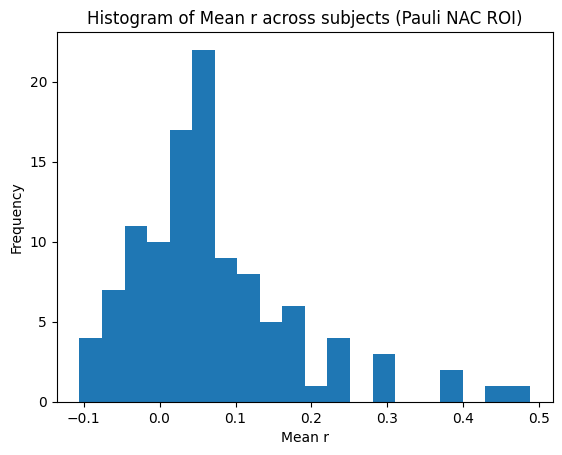

In [50]:
print(pd.Series(all_mean_rs).describe())

plt.hist(all_mean_rs, bins=20)
plt.xlabel('Mean r')
plt.ylabel('Frequency')
plt.title('Histogram of Mean r across subjects (Pauli NAC ROI)')
plt.show()